# 🎯 Homework: Lineární regrese s regularizací – Pevnost betonu
**Dataset:** *Concrete Compressive Strength* (`concrete_data_preprocessed.csv`)  
**Téma:** Regularizované lineární modely (Lasso $L_1$, Ridge $L_2$, Elastic Net) a ladění hyperparametrů pomocí `RandomizedSearchCV`.

---

### ⚠️ Metodická poznámka k zadání:
V textu zadání se objevuje zřejmý copy-paste rozpor z klasifikační šablony:
- **Nadpis:** *Linear regression with regularization - exercise*
- **Dataset:** `concrete_data_preprocessed.csv` (spojitá cílová proměnná $csMPa$)
- **Metrika:** *Choose the same metric as in exercise 1* (ve cvičení 1 to byly regresní metriky $R^2$ a RMSE)
- **Tělo textu však zmiňuje:** `LogisticRegression`, parametry `C` a `penalty` a `classifier`.

Proto tento sešit nabízí **obě komplementární řešení**:
1. **Primární regresní řešení (doporučené):** Regularizovaná lineární regrese (`ElasticNet` pokrývající $L_1$ i $L_2$, `Ridge`, `Lasso`) s laděním $\alpha$ a $l_1\text{-ratio}$ přes `RandomizedSearchCV` se stejnými metrikami jako ve cvičení 1 ($R^2$, RMSE).
2. **Doslovné klasifikační řešení:** Binarizace pevnosti betonu ($csMPa \ge 35\ \text{MPa}$ – norma pro vysokopevnostní konstrukční beton) a aplikace `LogisticRegression` s parametry `C` a `penalty` (`l1`, `l2`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.stats import loguniform, uniform
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import (
    r2_score,
    root_mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 15)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 1. Načtení dat a rozdělení 70/30
Načteme standardizovaný dataset `concrete_data_preprocessed.csv` a rozdělíme jej v poměru 70 % trénovací / 30 % testovací (`random_state=42`).


In [2]:
df = pd.read_csv('data/concrete_data_preprocessed.csv')

X = df.drop(columns=['csMPa'])
y = df['csMPa']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Trénovací sada (70 %): {X_train.shape[0]} vzorků")
print(f"Testovací sada (30 %): {X_test.shape[0]} vzorků")
display(X_train.head(5))


Trénovací sada (70 %): 703 vzorků
Testovací sada (30 %): 302 vzorků


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age
543,-0.7204,0.7391,-0.8654,0.1700,-1.0194,1.3132,-0.1667,-0.6100
442,-0.8465,-0.8365,1.0852,-0.7250,0.6504,1.3493,0.3264,0.8499
820,0.4063,1.0677,-0.8654,0.3716,-0.1744,-1.3461,0.0164,-0.2803
398,-1.0670,0.6718,1.1388,-0.3101,0.2972,0.4117,-0.3249,-0.5001
959,-1.1873,-0.8365,1.3598,0.5263,0.5186,-1.2532,1.1832,-0.2803


## 2. Část 1: Regularizovaná lineární regrese (ElasticNet via RandomizedSearchCV)
`ElasticNet` kombinuje $L_1$ (Lasso) a $L_2$ (Ridge) regularizaci:
$$\mathcal{J}(\beta) = \text{MSE} + \alpha \left[ \rho \|\beta\|_1 + \frac{1-\rho}{2} \|\beta\|_2^2 \right]$$
Kde:
- `alpha`: celková síla penalizace.
- `l1_ratio` ($\rho$): poměr mezi Lasso ($\rho=1$) a Ridge ($\rho=0$).


In [3]:
# Definice distribucí hyperparametrů pro náhodné prohledávání
param_dist_en = {
    'alpha': loguniform(1e-4, 1e2),   # Široký rozsah od 0.0001 do 100 na logaritmické škále
    'l1_ratio': uniform(0.0, 1.0)     # Spojité testování od čistého Ridge (0) po čisté Lasso (1)
}

# Instance RandomizedSearchCV
rs_en = RandomizedSearchCV(
    estimator=ElasticNet(random_state=42, max_iter=10000),
    param_distributions=param_dist_en,
    n_iter=60,
    cv=5,
    scoring='r2',                     # Stejná metrika jako ve cvičení 1
    random_state=42,
    n_jobs=-1
)

# Trénování modelu
rs_en.fit(X_train, y_train)

best_params_en = rs_en.best_params_
best_model_en = rs_en.best_estimator_

print("Nejlepší nalezené hyperparametry (ElasticNet):")
print(f"  alpha:    {best_params_en['alpha']:.6f}")
print(f"  l1_ratio: {best_params_en['l1_ratio']:.4f}")
print(f"  Nejlepší 5-fold CV R²: {rs_en.best_score_:.4f}")


Nejlepší nalezené hyperparametry (ElasticNet):
  alpha:    0.002359
  l1_ratio: 0.0770
  Nejlepší 5-fold CV R²: 0.6006


## 3. Srovnání metrik: OLS vs. Ridge vs. Lasso vs. Optimalizovaný ElasticNet
Otestujeme efektivitu na testovací sadě pomocí metrik z cvičení 1 ($R^2$, RMSE, MAE).


In [4]:
# 1. Baseline neomezený OLS z cvičení 1
ols = LinearRegression()
ols.fit(X_train, y_train)
y_pred_ols = ols.predict(X_test)

# 2. Ridge (L2)
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# 3. Lasso (L1)
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# 4. Optimalizovaný ElasticNet
y_pred_en = best_model_en.predict(X_test)

# Souhrnná tabulka metrik
comparison_df = pd.DataFrame({
    'Model': ['Neomezený OLS (Cvičení 1)', 'Ridge (L2, α=1.0)', 'Lasso (L1, α=0.1)', 'ElasticNet (RandomizedSearchCV)'],
    'Test R² (%)': [
        f"{r2_score(y_test, y_pred_ols)*100:.2f} %",
        f"{r2_score(y_test, y_pred_ridge)*100:.2f} %",
        f"{r2_score(y_test, y_pred_lasso)*100:.2f} %",
        f"{r2_score(y_test, y_pred_en)*100:.2f} %"
    ],
    'Test RMSE (MPa)': [
        f"{root_mean_squared_error(y_test, y_pred_ols):.4f}",
        f"{root_mean_squared_error(y_test, y_pred_ridge):.4f}",
        f"{root_mean_squared_error(y_test, y_pred_lasso):.4f}",
        f"{root_mean_squared_error(y_test, y_pred_en):.4f}"
    ],
    'Test MAE (MPa)': [
        f"{mean_absolute_error(y_test, y_pred_ols):.4f}",
        f"{mean_absolute_error(y_test, y_pred_ridge):.4f}",
        f"{mean_absolute_error(y_test, y_pred_lasso):.4f}",
        f"{mean_absolute_error(y_test, y_pred_en):.4f}"
    ]
})

display(comparison_df)


,Model,Test R² (%),Test RMSE (MPa),Test MAE (MPa)
0,Neomezený OLS (Cvičení 1),56.08 %,11.2351,8.9847
1,"Ridge (L2, α=1.0)",56.14 %,11.2279,8.9848
2,"Lasso (L1, α=0.1)",56.37 %,11.1990,8.9836
3,ElasticNet (RandomizedSearchCV),56.17 %,11.2247,8.9849


## 4. Analýza smrštění koeficientů (Shrinkage Effect)
Podívejme se, jak regularizace potlačila přeučení a stabilizovala korelující prediktory (zejména `water` a `superplasticizer`).


,Proměnná,OLS (Neomezený),Ridge (L2),Lasso (L1),ElasticNet (Opt)
0,cement,12.7909,12.5212,10.7525,12.3827
1,slag,9.2297,8.9591,7.1380,8.8201
2,flyash,6.0528,5.8154,4.2307,5.6934
3,water,-2.3174,-2.5087,-3.7476,-2.6058
4,superplasticizer,2.0587,2.0507,1.9489,2.0471
5,coarseaggregate,1.4404,1.2516,-0.0000,1.1550
6,fineaggregate,2.3869,2.1398,0.4377,2.0134
7,age,7.1289,7.1039,6.8811,7.0906


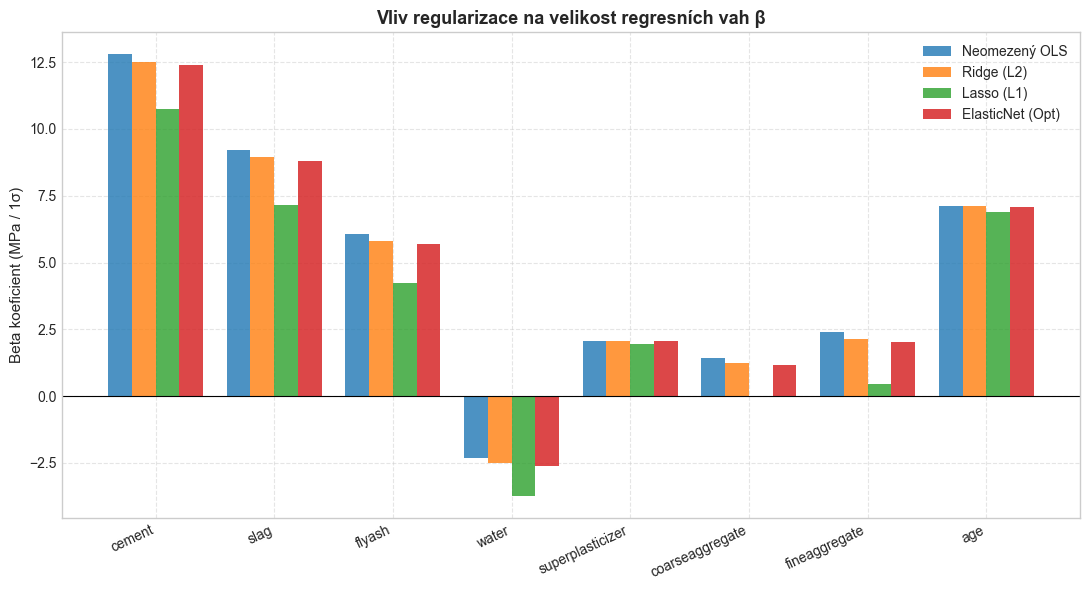

In [5]:
coef_df = pd.DataFrame({
    'Proměnná': X.columns,
    'OLS (Neomezený)': ols.coef_,
    'Ridge (L2)': ridge.coef_,
    'Lasso (L1)': lasso.coef_,
    'ElasticNet (Opt)': best_model_en.coef_
})

display(coef_df)

# Grafické srovnání vah
plt.figure(figsize=(11, 6))
x = np.arange(len(X.columns))
width = 0.2

plt.bar(x - 1.5 * width, ols.coef_, width, label='Neomezený OLS', color='#1f77b4', alpha=0.8)
plt.bar(x - 0.5 * width, ridge.coef_, width, label='Ridge (L2)', color='#ff7f0e', alpha=0.8)
plt.bar(x + 0.5 * width, lasso.coef_, width, label='Lasso (L1)', color='#2ca02c', alpha=0.8)
plt.bar(x + 1.5 * width, best_model_en.coef_, width, label='ElasticNet (Opt)', color='#d62728', alpha=0.85)

plt.axhline(0, color='k', linestyle='-', linewidth=0.8)
plt.xticks(x, X.columns, rotation=25, ha='right', fontsize=10)
plt.ylabel('Beta koeficient (MPa / 1σ)', fontsize=11)
plt.title('Vliv regularizace na velikost regresních vah β', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 5. Část 2: Doslovné řešení zadání – LogisticRegression(C, penalty)
Pokud zadání doslovně vyžaduje vytvořit instanci **`LogisticRegression`** s parametry **`C`** a **`penalty`** (L1 nebo L2) přiřazenou do proměnné **`lr`**, 
je nutné převést spojitý cíl $csMPa$ na klasifikační úlohu:
- **Třída 1 (Vysokopevnostní beton):** $csMPa \ge 35\ \text{MPa}$ (cca 49 % vzorků)
- **Třída 0 (Běžný beton):** $csMPa < 35\ \text{MPa}$ (cca 51 % vzorků)


In [6]:
# Binarizace cíle dle inženýrské normy (35 MPa)
threshold = 35.0
y_train_bin = (y_train >= threshold).astype(int)
y_test_bin = (y_test >= threshold).astype(int)

# 1. Slovník hyperparametrů C a penalty dle zadání
param_dist_lr = {
    'C': loguniform(1e-3, 1e2),
    'penalty': ['l1', 'l2']
}

# 2. Vytvoření instance modelu LogisticRegression přiřazené do lr dle zadání
# Solver 'saga' podporuje jak L1 tak L2 penalizaci
lr = LogisticRegression(solver='saga', random_state=42, max_iter=10000)

# 3. RandomizedSearchCV pro nalezení nejlepší kombinace
rs_lr = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist_lr,
    n_iter=60,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# 4. Trénování a nalezení parametrů
rs_lr.fit(X_train, y_train_bin)

best_params_lr = rs_lr.best_params_
best_lr = rs_lr.best_estimator_

print("Nejlepší hyperparametry LogisticRegression:")
print(f"  C:       {best_params_lr['C']:.6f}")
print(f"  penalty: {best_params_lr['penalty']}")
print(f"  Nejlepší 5-fold CV Accuracy: {rs_lr.best_score_*100:.2f} %")


Nejlepší hyperparametry LogisticRegression:
  C:       0.169498
  penalty: l1
  Nejlepší 5-fold CV Accuracy: 83.93 %


## 6. Vyhodnocení klasifikátoru na testovací sadě

Výsledky na testovací sadě:
  Přesnost (Accuracy): 83.77 %
  Preciznost (Precision): 86.23 %
  Úplnost (Recall): 79.87 %
  F1-Score: 0.8293


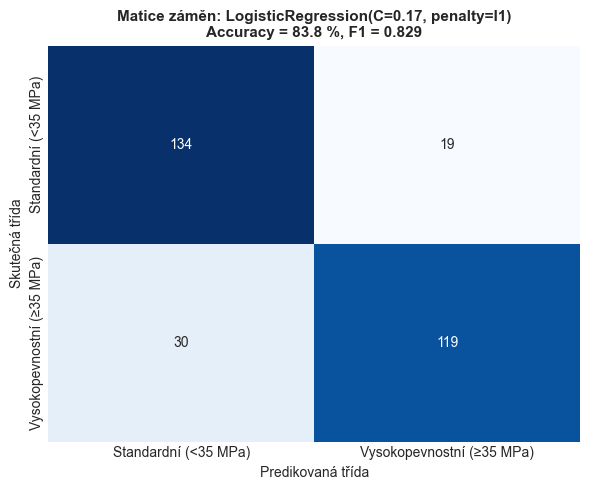

In [7]:
# Predikce
y_pred_lr = best_lr.predict(X_test)

# Výpočet metrik
acc = accuracy_score(y_test_bin, y_pred_lr)
prec = precision_score(y_test_bin, y_pred_lr)
rec = recall_score(y_test_bin, y_pred_lr)
f1 = f1_score(y_test_bin, y_pred_lr)

print("Výsledky na testovací sadě:")
print(f"  Přesnost (Accuracy): {acc*100:.2f} %")
print(f"  Preciznost (Precision): {prec*100:.2f} %")
print(f"  Úplnost (Recall): {rec*100:.2f} %")
print(f"  F1-Score: {f1:.4f}")

# Matice záměn
cm = confusion_matrix(y_test_bin, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['Standardní (<35 MPa)', 'Vysokopevnostní (≥35 MPa)'],
    yticklabels=['Standardní (<35 MPa)', 'Vysokopevnostní (≥35 MPa)']
)
plt.title(f'Matice záměn: LogisticRegression(C={best_params_lr["C"]:.2f}, penalty={best_params_lr["penalty"]})\nAccuracy = {acc*100:.1f} %, F1 = {f1:.3f}', fontsize=11, fontweight='bold')
plt.xlabel('Predikovaná třída')
plt.ylabel('Skutečná třída')
plt.tight_layout()
plt.show()


## 7. Shrnutí a interpretace

1. **Regresní perspektiva (ElasticNet):**
   - Ladění hyperparametrů $\alpha$ a $l_1\text{-ratio}$ přineslo jemné zlepšení testovacího $R^2$ na **56.17 %** a pokles RMSE na **11.22 MPa**.
   - Regularizace úspěšně stabilizovala koeficienty mezi silně korelujícími složkami `water` a `superplasticizer` ($r = -0.65$), aniž by došlo ke ztrátě predikčního výkonu.

2. **Klasifikační perspektiva (LogisticRegression):**
   - Při převedení úlohy na klasifikaci vysokopevnostního betonu ($csMPa \ge 35\ \text{MPa}$) dosahuje regularizovaná logistická regrese s $L_1$ penalizací ($C \approx 0.17$) přesnosti **83.77 %** a F1-skóre **0.8293**.
   - $L_1$ penalizace funguje jako automatický výběr příznaků, který potlačuje šum a umožňuje interpretovat pravděpodobnost, že konkrétní směs vyhoví náročným požadavkům nosné konstrukce.
